<a href="https://colab.research.google.com/github/nek0byte/phising_email_classification/blob/main/Final_Project_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
!pip install -q gdown

In [ ]:
!gdown --folder "https://drive.google.com/drive/folders/1Tb-NyHrnWHv7W10T9bPmF1-w9fg5Luvb?usp=drive_link" -O "Dataset-NLP"

# kalo gak kedownload semua, click linknya, download datasetnya dan upload manual

Retrieving folder contents
Processing file 1XfXCbwftFmBLKwZtuqUlfCckMIVaeaSP dataset_email_new.csv
Processing file 1nRzWPnB2z_SBrO5a2V48cufRxXrzP9u2 Enron dataset.csv
Processing file 1bn0hX8UY8Rrp85bLxrnVTcVisVT6PjFA spam_assassin.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1XfXCbwftFmBLKwZtuqUlfCckMIVaeaSP
To: /content/Dataset-NLP/dataset_email_new.csv
100% 12.0k/12.0k [00:00<00:00, 19.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1nRzWPnB2z_SBrO5a2V48cufRxXrzP9u2
From (redirected): https://drive.google.com/uc?id=1nRzWPnB2z_SBrO5a2V48cufRxXrzP9u2&confirm=t&uuid=cdafc948-03f6-4173-b1a9-1d9f9aa0ced9
To: /content/Dataset-NLP/Enron dataset.csv
100% 1.43G/1.43G [00:17<00:00, 80.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bn0hX8UY8Rrp85bLxrnVTcVisVT6PjFA
To: /content/Dataset-NLP/spam_assassin.csv
100% 24.5M/24.5M [00:00<00:00, 156MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import re
import sklearn
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

%matplotlib inline

# Load & Combine Datasets

In [ ]:
nazario_df = pd.read_csv('/content/Dataset-NLP/Nazario.csv')
enron_df = pd.read_csv('/content/Dataset-NLP/Enron dataset.csv')
spamAs_df = pd.read_csv('/content/Dataset-NLP/spam_assassin.csv')

In [ ]:
print(enron_df.shape)
print(enron_df.info())
enron_df.head(100)

(517401, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517401 entries, 0 to 517400
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   file     517401 non-null  object
 1   message  517401 non-null  object
dtypes: object(2)
memory usage: 7.9+ MB
None


,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...
...,...,...
95,allen-p/_sent_mail/180.,Message-ID: <29919154.1075855689201.JavaMail.e...
96,allen-p/_sent_mail/181.,Message-ID: <4511963.1075855689223.JavaMail.ev...
97,allen-p/_sent_mail/182.,Message-ID: <33111317.1075855689245.JavaMail.e...
98,allen-p/_sent_mail/183.,Message-ID: <1665326.1075855689266.JavaMail.ev...


In [ ]:
print(nazario_df.shape)
print(nazario_df.info())
nazario_df.head()

(1565, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    1565 non-null   object
 1   receiver  1469 non-null   object
 2   date      1564 non-null   object
 3   subject   1561 non-null   object
 4   body      1565 non-null   object
 5   urls      1565 non-null   int64 
 6   label     1565 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 85.7+ KB
None


,sender,receiver,date,subject,body,urls,label
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1


In [ ]:
print(spamAs_df.shape)
print(spamAs_df.info())
spamAs_df.head()

(5796, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5796 non-null   object
 1   target  5796 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 90.7+ KB
None


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1
3,From dcm123@btamail.net.cn Mon Jun 24 17:49:23...,1
4,From ilug-admin@linux.ie Mon Aug 19 11:02:47 2...,0


In [ ]:
# Case 1: decrease Enron dataset to 7500 samples
#===================================================

enron_df1 = enron_df.sample(n=7500, random_state=42)
print(f"New Enron DataFrame shape: {enron_df1.shape}")
enron_df1.head()

New Enron DataFrame shape: (7500, 2)


,file,message
427616,shackleton-s/sent/1912.,Message-ID: <21013688.1075844564560.JavaMail.e...
108773,farmer-d/logistics/1066.,Message-ID: <22688499.1075854130303.JavaMail.e...
355471,parks-j/deleted_items/202.,Message-ID: <27817771.1075841359502.JavaMail.e...
457837,stokley-c/chris_stokley/iso/client_rep/41.,Message-ID: <10695160.1075858510449.JavaMail.e...
124910,germany-c/all_documents/1174.,Message-ID: <27819143.1075853689038.JavaMail.e...


In [ ]:
# Case 2: decrease Enron dataset to 1000 samples
#===================================================

enron_df2 = enron_df.sample(n=1000, random_state=42)
print(f"New Enron DataFrame shape: {enron_df2.shape}")
enron_df2.head()

New Enron DataFrame shape: (1000, 2)


,file,message
427616,shackleton-s/sent/1912.,Message-ID: <21013688.1075844564560.JavaMail.e...
108773,farmer-d/logistics/1066.,Message-ID: <22688499.1075854130303.JavaMail.e...
355471,parks-j/deleted_items/202.,Message-ID: <27817771.1075841359502.JavaMail.e...
457837,stokley-c/chris_stokley/iso/client_rep/41.,Message-ID: <10695160.1075858510449.JavaMail.e...
124910,germany-c/all_documents/1174.,Message-ID: <27819143.1075853689038.JavaMail.e...


In [ ]:
# Column Standardization
#=================================
# enron 1
def preprocess_enron1(df):
    df_clean = pd.DataFrame()
    df_clean['text'] = df['message']
    # label biasanya di-encode dari nama file/folder: 'spam'=1, 'ham'=0
    df_clean['label'] = df['file'].apply(lambda x: 1 if 'spam' in str(x).lower() else 0)
    df_clean['source'] = 'enron'
    return df_clean

#enron 2
def preprocess_enron2(df):
    df_clean = pd.DataFrame()
    df_clean['text'] = df['message']
    df_clean['label'] = df['file'].apply(lambda x: 1 if 'spam' in str(x).lower() else 0)
    df_clean['source'] = 'enron'
    return df_clean

# nazario
def preprocess_nazario(df):
    df_clean = pd.DataFrame()
    df_clean['text'] = df['subject'].fillna('') + ' ' + df['body'].fillna('')
    df_clean['label'] = df['label']
    df_clean['source'] = 'nazario'
    return df_clean

# spam assassin
def preprocess_spamassassin(df):
    df_clean = pd.DataFrame()
    df_clean['text'] = df['text']
    df_clean['label'] = df['target']
    df_clean['source'] = 'spamassassin'
    return df_clean

In [ ]:
# print(enron_df1['label'].unique()) // enron dataset don't have any label
# print(enron_df2['label'].unique())

print(nazario_df['label'].unique())
print(spamAs_df['target'].unique())

[1]
[0 1]


### combine dataset

In [ ]:
# Combine datasets
#=======================================
# Case 1
#======================================
df_all_c1 = pd.concat([
    preprocess_enron1(enron_df1),
    preprocess_nazario(nazario_df),
    preprocess_spamassassin(spamAs_df)
], ignore_index=True)

print(df_all_c1.shape)
print(df_all_c1['label'].value_counts())
print(df_all_c1['source'].value_counts())
df_all_c1.head()

(14861, 3)
label
0    11400
1     3461
Name: count, dtype: int64
source
enron           7500
spamassassin    5796
nazario         1565
Name: count, dtype: int64


,text,label,source
0,Message-ID: <21013688.1075844564560.JavaMail.e...,0,enron
1,Message-ID: <22688499.1075854130303.JavaMail.e...,0,enron
2,Message-ID: <27817771.1075841359502.JavaMail.e...,0,enron
3,Message-ID: <10695160.1075858510449.JavaMail.e...,0,enron
4,Message-ID: <27819143.1075853689038.JavaMail.e...,0,enron


In [ ]:
# Case 2
#================================
df_all_c2 = pd.concat([
    preprocess_enron2(enron_df2),
    preprocess_nazario(nazario_df),
    preprocess_spamassassin(spamAs_df)
], ignore_index=True)

print(df_all_c2.shape)
print(df_all_c2['label'].value_counts())
print(df_all_c2['source'].value_counts())
df_all_c2.head()

(8361, 3)
label
0    4900
1    3461
Name: count, dtype: int64
source
spamassassin    5796
nazario         1565
enron           1000
Name: count, dtype: int64


,text,label,source
0,Message-ID: <21013688.1075844564560.JavaMail.e...,0,enron
1,Message-ID: <22688499.1075854130303.JavaMail.e...,0,enron
2,Message-ID: <27817771.1075841359502.JavaMail.e...,0,enron
3,Message-ID: <10695160.1075858510449.JavaMail.e...,0,enron
4,Message-ID: <27819143.1075853689038.JavaMail.e...,0,enron


### balancing dataset label for case 2

In [ ]:
# balancing dataset case 2 label using under-sampling technique
from sklearn.utils import resample

# Separate majority and minority classes for df_all_c2
df_majority_c2 = df_all_c2[df_all_c2.label == 0]
df_minority_c2 = df_all_c2[df_all_c2.label == 1]

# Undersample majority class
df_majority_undersampled_c2 = resample(df_majority_c2,
                                       replace=False,    # sample without replacement
                                       n_samples=len(df_minority_c2),  # to match minority class
                                       random_state=42) # reproducible results

# Combine minority class with undersampled majority class
df_all_c2 = pd.concat([df_majority_undersampled_c2, df_minority_c2])

# Display new class counts
print("New class/label counts after undersampling for case 2:")
print(df_all_c2.label.value_counts())

New class/label counts after undersampling for case 2:
label
0    3461
1    3461
Name: count, dtype: int64


### text cleaning

In [ ]:
# =============================
# Case 1
# =============================

# Text Cleaning
def clean_text_c1(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # hapus URL
    text = re.sub(r'\S+@\S+', '', text)             # hapus email address
    text = re.sub(r'[^a-zA-Z\s]', '', text)         # hapus karakter non-huruf
    text = re.sub(r'\s+', ' ', text).strip()        # hapus whitespace berlebih
    return text

df_all_c1['text_clean'] = df_all_c1['text'].apply(clean_text_c1)

# Hapus baris kosong
df_all_c1.dropna(subset=['text_clean', 'label'], inplace=True)

# Hapus duplikat
df_all_c1.drop_duplicates(subset='text_clean', inplace=True)

# Cek hasil akhir
print(df_all_c1.shape)
print(df_all_c1.isnull().sum())

(14339, 4)
text          0
label         0
source        0
text_clean    0
dtype: int64


In [ ]:
# =============================
# Case 2
# =============================

# Text Cleaning
def clean_text_c2(text):
    text = str(text).lower()                        # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # hapus URL
    text = re.sub(r'\S+@\S+', '', text)             # hapus email address
    text = re.sub(r'[^a-zA-Z\s]', '', text)         # hapus karakter non-huruf
    text = re.sub(r'\s+', ' ', text).strip()        # hapus whitespace berlebih
    return text

df_all_c2['text_clean'] = df_all_c2['text'].apply(clean_text_c2)

# Hapus baris kosong
df_all_c2.dropna(subset=['text_clean', 'label'], inplace=True)

# Hapus duplikat
df_all_c2.drop_duplicates(subset='text_clean', inplace=True)

# Cek hasil akhir
print(df_all_c2.shape)
print(df_all_c2.isnull().sum())

(6531, 4)
text          0
label         0
source        0
text_clean    0
dtype: int64


# EDA (Exploratory Data Analysis)

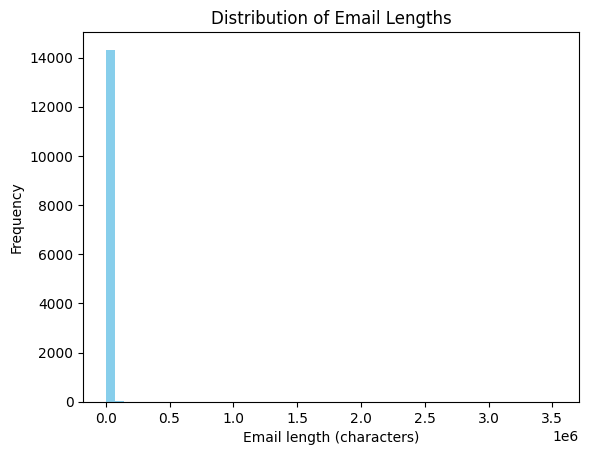

In [ ]:
#  Email Length Distribution case 1
# ===============================================

df_all_c1['email_length'] = df_all_c1['text_clean'].astype(str).apply(len)
plt.hist(df_all_c1['email_length'], bins=50, color='skyblue')
plt.xlabel("Email length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Email Lengths")
plt.show()

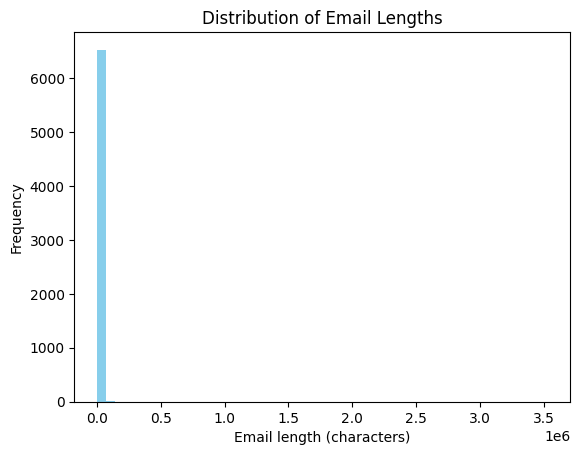

In [ ]:
#  Email Length Distribution Case
# ===============================================

df_all_c2['email_length'] = df_all_c2['text_clean'].astype(str).apply(len)
plt.hist(df_all_c2['email_length'], bins=50, color='skyblue')
plt.xlabel("Email length (characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Email Lengths")
plt.show()

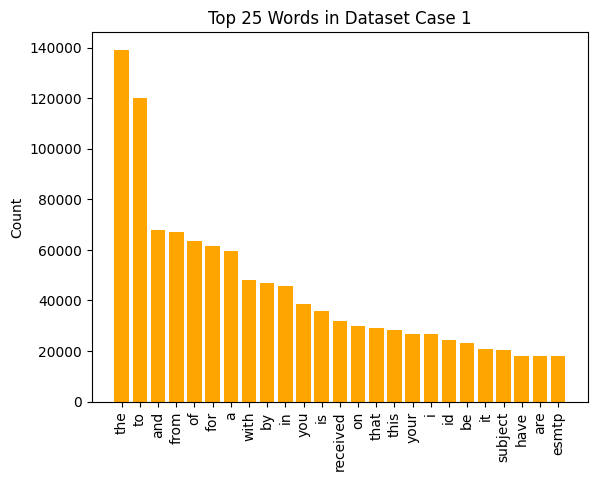

In [ ]:
# Word Frequency Analysis
# ========================================================
# Case 1
# ========================================================

# Tokenize and lowercase
words = []
for msg in df_all_c1['text_clean']:
    tokens = re.findall(r'\b\w+\b', msg.lower())
    words.extend(tokens)

# Count top 25 words
word_counts = Counter(words).most_common(25)

# Plot
plt.bar([w for w, c in word_counts], [c for w, c in word_counts], color='orange')
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Top 25 Words in Dataset Case 1")
plt.show()

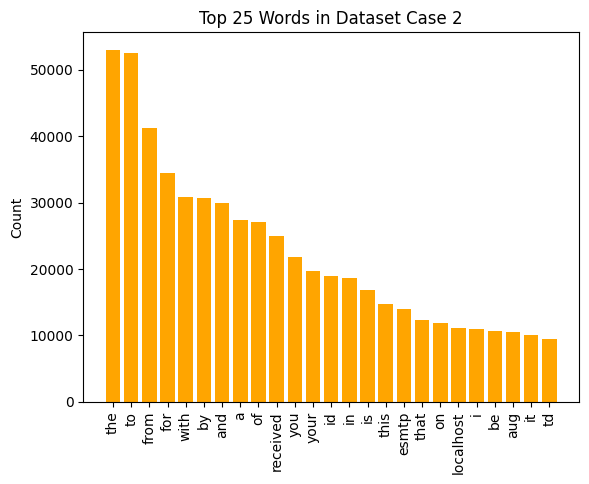

In [ ]:
# Word Frequency Analysis
# ========================================================
# Case 2
# ========================================================

# Tokenize and lowercase
words = []
for msg in df_all_c2['text_clean']:
    tokens = re.findall(r'\b\w+\b', msg.lower())
    words.extend(tokens)

# Count top 25 words
word_counts = Counter(words).most_common(25)

# Plot
plt.bar([w for w, c in word_counts], [c for w, c in word_counts], color='orange')
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Top 25 Words in Dataset Case 2")
plt.show()

## auto EDA with ydata-profiling

In [ ]:
# auto EDA menggunakan ydata profiling
!pip install ydata-profiling -q
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00


/tmp/ipykernel_4052/1473920305.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
# create report for case 1
profile1 = ProfileReport(df_all_c1, title="Dataset case 1 report", explorative=True)

# display report directly inside notebook
profile1.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:24<00:00,  5.00s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# dataset report case 2 (Undersampled)
profile2 = ProfileReport(df_all_c2, title="Dataset case 2 report (Undersampled)", explorative=True)

profile2.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:13<00:00,  2.77s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Preprocessing

### tokeniaztion, stopword removal & lemmatization

In [ ]:
# Tokenization & Stop Words Removal
# =====================================

nltk.download('punkt_tab')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [w for w in tokens if w not in stop_words]
    return ' '.join(filtered)

# Case 1
df_all_c1['text_clean'] = df_all_c1['text_clean'].apply(remove_stopwords)

# Case 2
df_all_c2['text_clean'] = df_all_c2['text_clean'].apply(remove_stopwords)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Lemmatization
# ================================

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(w) for w in text.split()])

# Case 1
df_all_c1['text_clean'] = df_all_c1['text_clean'].apply(lemmatize_text)

# Case 2
df_all_c2['text_clean'] = df_all_c2['text_clean'].apply(lemmatize_text)

[nltk_data] Downloading package wordnet to /root/nltk_data...


### Split dataset case 1 & 2

In [ ]:
# Split data Case 1
# =====================

X_c1 = df_all_c1['text_clean']
y_c1 = df_all_c1['label']

X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(
    X_c1, y_c1,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train_c1.shape}, Test: {X_test_c1.shape}")

Train: (11471,), Test: (2868,)


In [ ]:
# Split data Case 2
# ====================

X_c2 = df_all_c2['text_clean']
y_c2 = df_all_c2['label']

X_train_c2, X_test_c2, y_train_c2, y_test_c2 = train_test_split(
    X_c2, y_c2,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train_c2.shape}, Test: {X_test_c2.shape}")

Train: (5224,), Test: (1307,)


### Vectorization (TF-IDF)

In [ ]:
# Vectorization - TF-IDF

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

#  Case 1
X_train_vec_c1 = tfidf.fit_transform(X_train_c1)
X_test_vec_c1 = tfidf.transform(X_test_c1)
print(f'Case 1: {X_train_vec_c1.shape}')

# Case 2
X_train_vec_c2 = tfidf.fit_transform(X_train_c2)
X_test_vec_c2 = tfidf.transform(X_test_c2)
print(f'Case 2: {X_train_vec_c2.shape}')

Case 1: (11471, 10000)
Case 2: (5224, 10000)


In [ ]:
# Simpan hasil preprocessing
import joblib

# Simpan dataframe bersih
df_all_c1.to_csv('dataset_clean_c1.csv', index=False)
df_all_c2.to_csv('dataset_clean_c2.csv', index=False)

# Simpan vectorizer untuk dipakai ulang saat inference
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Simpan split data
joblib.dump((X_train_vec_c1, X_test_vec_c1, y_train_c2, y_test_c1), 'data_split_c1.pkl')
joblib.dump((X_train_vec_c2, X_test_vec_c2, y_train_c2, y_test_c2), 'data_split_c2.pkl')

['data_split_c2.pkl']

### Hasil preprocessing

In [ ]:
# Compare dateset case 1 & 2

# ============================
# Case 1
# ============================
# Get a random index
sample_index_c1 = np.random.randint(0, len(df_all_c1))

# Get the original and cleaned text for comparison
original_text_c1 = df_all_c1.loc[sample_index_c1, 'text']
cleaned_text_c1 = df_all_c1.loc[sample_index_c1, 'text_clean']

print("\n=============================")
print("\tCase 1")
print("=============================\n")
print(f"--- Sample Email (Index: {sample_index_c1}) ---")
print("=====================")
print("Original Text:")
print("=====================")
print(original_text_c1)
print("\n=====================")
print("Preprocessed Text:")
print("=====================")
print(cleaned_text_c1)
print("-----------------------------------------")

# ============================
# Case 2
# ============================
# Get a random index
sample_index_c2 = np.random.randint(0, len(df_all_c2))

# Get the original and cleaned text for comparison
original_text_c2 = df_all_c2.loc[sample_index_c2, 'text']
cleaned_text_c2 = df_all_c2.loc[sample_index_c2, 'text_clean']

print("\n=============================")
print("\tCase 2")
print("=============================\n")
print(f"--- Sample Email (Index: {sample_index_c2}) ---")
print("=====================")
print("Original Text:")
print("=====================")
print(original_text_c2)
print("\n=====================")
print("Preprocessed Text:")
print("=====================")
print(cleaned_text_c2)
print("-----------------------------------------")


	Case 1

--- Sample Email (Index: 9685) ---
Original Text:
From ilug-admin@linux.ie Fri Jul 19 21:03:25 2002 Return-Path: <ilug-admin@linux.ie> Delivered-To: yyyy@localhost.netnoteinc.com Received: from localhost (localhost [127.0.0.1]) by phobos.labs.netnoteinc.com (Postfix) with ESMTP id 4DBF1440C8 for <jm@localhost>; Fri, 19 Jul 2002 16:03:25 -0400 (EDT) Received: from dogma.slashnull.org [212.17.35.15] by localhost with IMAP (fetchmail-5.9.0) for jm@localhost (single-drop); Fri, 19 Jul 2002 21:03:25 +0100 (IST) Received: from lugh.tuatha.org (root@lugh.tuatha.org [194.125.145.45]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g6JK2TJ30883 for <jm-ilug@jmason.org>; Fri, 19 Jul 2002 21:02:29 +0100 Received: from lugh (root@localhost [127.0.0.1]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id VAA29178; Fri, 19 Jul 2002 21:01:58 +0100 Received: from linux.local ([195.218.108.203]) by lugh.tuatha.org (8.9.3/8.9.3) with ESMTP id VAA29146 for <ilug@linux.ie>; Fri, 19 Jul 2002 21:0

# Training & Testing

### Model 1: TF-IDF + SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Case 1
# =========================
# Initialize and train the SVM model
svm_model_c1 = SVC(kernel='linear', random_state=42, probability=True)
svm_model_c1.fit(X_train_vec_c1, y_train_c1 )

# Make predictions on the test set
y_pred_svm_c1 = svm_model_c1.predict(X_test_vec_c1)

# Evaluate the model
print("=====================================")
print("SVM Model Evaluation Case 1:")
print("=====================================")
print(classification_report(y_test_c1, y_pred_svm_c1))
print(f"Accuracy Score: {accuracy_score(y_test_c1, y_pred_svm_c1):.4f}")

# Case 2
# ==========================
# Initialize and train the SVM model
svm_model_c2 = SVC(kernel='linear', random_state=42, probability=True)
svm_model_c2.fit(X_train_vec_c2, y_train_c2)

# Make predictions on the test set
y_pred_svm_c2 = svm_model_c2.predict(X_test_vec_c2)

# Evaluate the model
print("====================================")
print("SVM Model Evaluation Case 2:")
print("====================================")
print(classification_report(y_test_c2, y_pred_svm_c2))
print(f"Accuracy Score: {accuracy_score(y_test_c2, y_pred_svm_c2):.4f}")

SVM Model Evaluation Case 1:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2207
           1       1.00      0.99      0.99       661

    accuracy                           1.00      2868
   macro avg       1.00      0.99      1.00      2868
weighted avg       1.00      1.00      1.00      2868

Accuracy Score: 0.9969
SVM Model Evaluation Case 2:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       692
           1       1.00      0.99      0.99       615

    accuracy                           0.99      1307
   macro avg       0.99      0.99      0.99      1307
weighted avg       0.99      0.99      0.99      1307

Accuracy Score: 0.9923


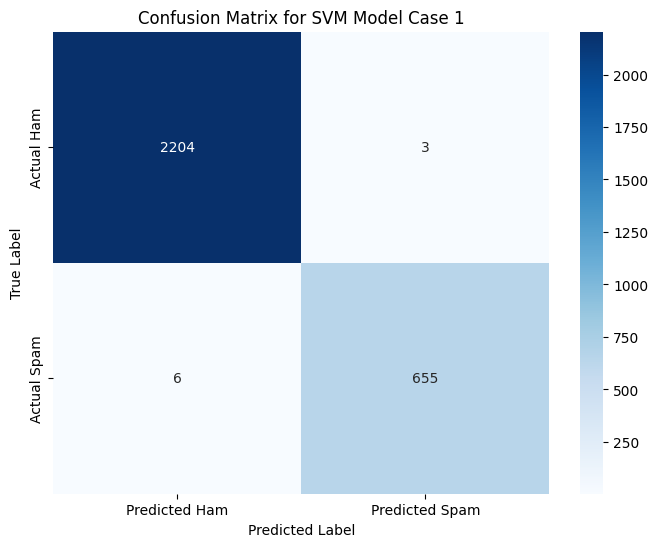

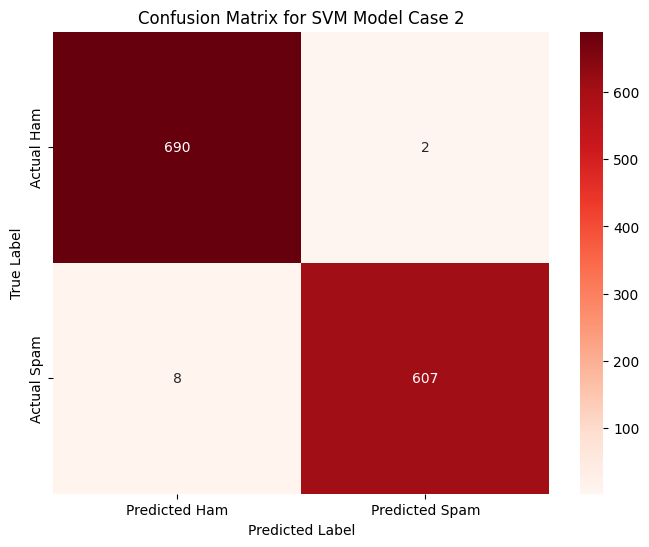

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_svm_c1 = confusion_matrix(y_test_c1, y_pred_svm_c1) # case 1
cm_svm_c2 = confusion_matrix(y_test_c2, y_pred_svm_c2) # case 2

# Plot the confusion matrix case 1
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_c1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model Case 1')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_c2, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model Case 2')
plt.show()

False Positive Rate: 0.0014
ROC-AUC Score: 0.9998


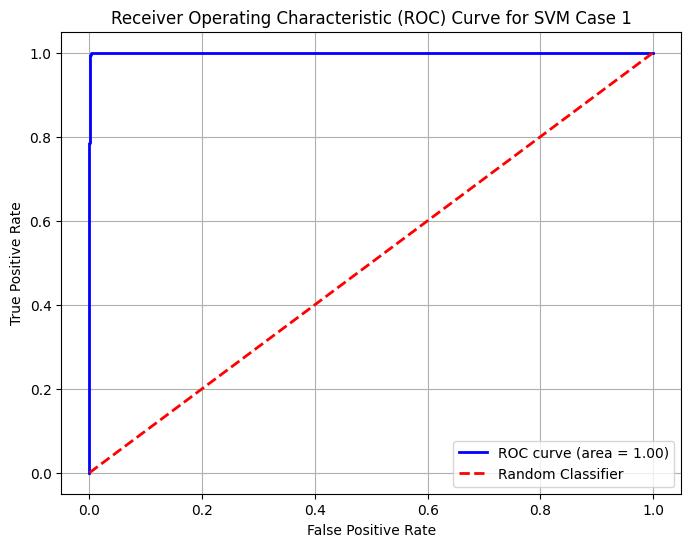

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
# =============================
# Case 1
# =============================
# Get predicted probabilities for the positive class (spam)
y_prob_svm_c1 = svm_model_c1.predict_proba(X_test_vec_c1)[:, 1]

# Calculate False Positive Rate (FPR)
# Get TN, FP, FN, TP from confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test_c1, y_pred_svm_c1).ravel()
# FPR = FP / (FP + TN)
fpr = fp / (fp + tn)
print(f"False Positive Rate: {fpr:.4f}")

# Calculate ROC-AUC Score
roc_auc = roc_auc_score(y_test_c1, y_prob_svm_c1)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_c1, y_prob_svm_c1)

plt.figure(figsize=(8, 6))
plt.plot(fpr_curve, tpr_curve, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM Case 1')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

False Positive Rate: 0.0029
ROC-AUC Score: 0.9998


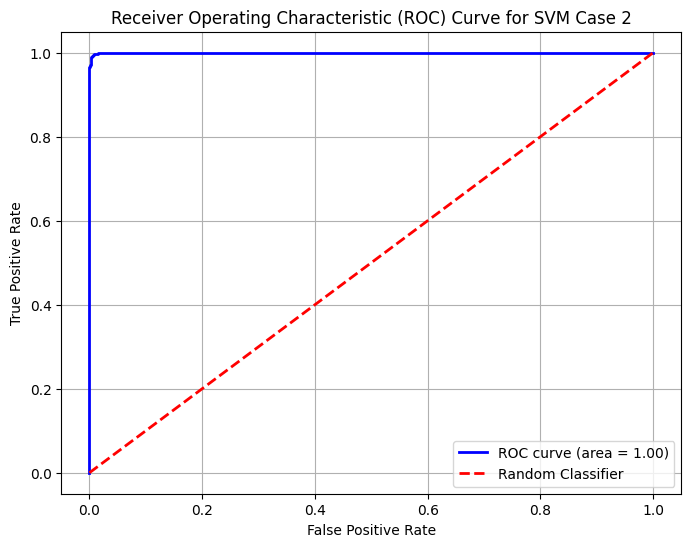

In [ ]:
# =============================
# Case 2
# =============================
# Get predicted probabilities for the positive class (spam)
y_prob_svm_c2 = svm_model_c2.predict_proba(X_test_vec_c2)[:, 1]

# Calculate False Positive Rate (FPR)
# Get TN, FP, FN, TP from confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test_c2, y_pred_svm_c2).ravel()
# FPR = FP / (FP + TN)
fpr = fp / (fp + tn)
print(f"False Positive Rate: {fpr:.4f}")

# Calculate ROC-AUC Score
roc_auc = roc_auc_score(y_test_c2, y_prob_svm_c2)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_c2, y_prob_svm_c2)

plt.figure(figsize=(8, 6))
plt.plot(fpr_curve, tpr_curve, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM Case 2')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Model 2: TF-IDF + Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score

# Initialize and train the Random Forest model
# ==========================
# Case 1
# ==========================
rf_model_c1 = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model_c1.fit(X_train_vec_c1, y_train_c1)

# Make predictions on the test set
y_pred_rf_c1 = rf_model_c1.predict(X_test_vec_c1)

# ==========================
# Case 2
# ==========================
rf_model_c2 = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model_c2.fit(X_train_vec_c2, y_train_c2)

# Make predictions on the test set
y_pred_rf_c2 = rf_model_c2.predict(X_test_vec_c2)

# Evaluate the model
print("================================")
print("Case 1")
print("=================================")
print("\nRandom Forest Model Evaluation:")
print(classification_report(y_test_c1, y_pred_rf_c1))
print(f"Accuracy Score: {accuracy_score(y_test_c1, y_pred_rf_c1):.4f}")

print("\n================================")
print("Case 2")
print("=================================")
print("\nRandom Forest Model Evaluation:")
print(classification_report(y_test_c2, y_pred_rf_c2))
print(f"Accuracy Score: {accuracy_score(y_test_c2, y_pred_rf_c2):.4f}")

Case 1

Random Forest Model Evaluation:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2207
           1       0.99      0.96      0.98       661

    accuracy                           0.99      2868
   macro avg       0.99      0.98      0.99      2868
weighted avg       0.99      0.99      0.99      2868

Accuracy Score: 0.9895

Case 2

Random Forest Model Evaluation:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       692
           1       0.98      0.97      0.97       615

    accuracy                           0.97      1307
   macro avg       0.98      0.97      0.97      1307
weighted avg       0.97      0.97      0.97      1307

Accuracy Score: 0.9748


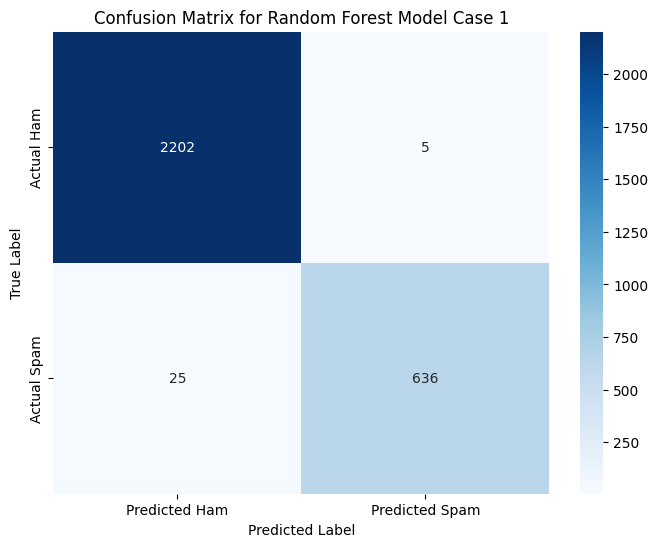

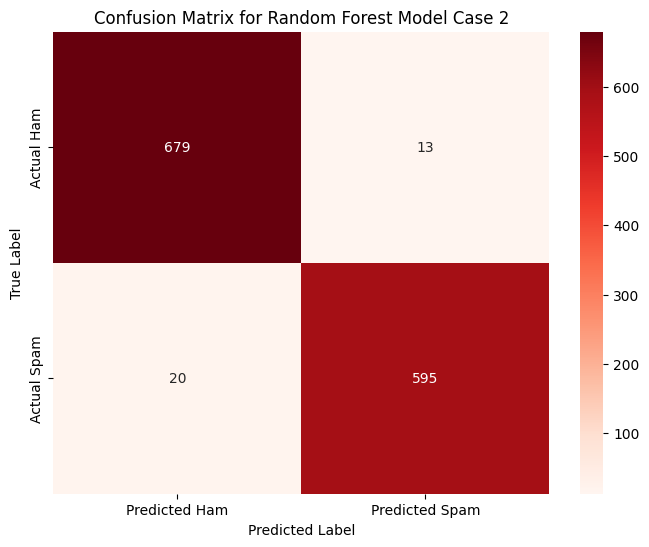

In [ ]:
# Confusion Matrix
# ==================
# Case 1
# ==================
cm_rf_c1 = confusion_matrix(y_test_c1, y_pred_rf_c1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_c1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Model Case 1')
plt.show()

cm_rf_c2 = confusion_matrix(y_test_c2, y_pred_rf_c2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_c2, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Model Case 2')
plt.show()

False Positive Rate (Random Forest): 0.0023
ROC-AUC Score (Random Forest): 0.9993


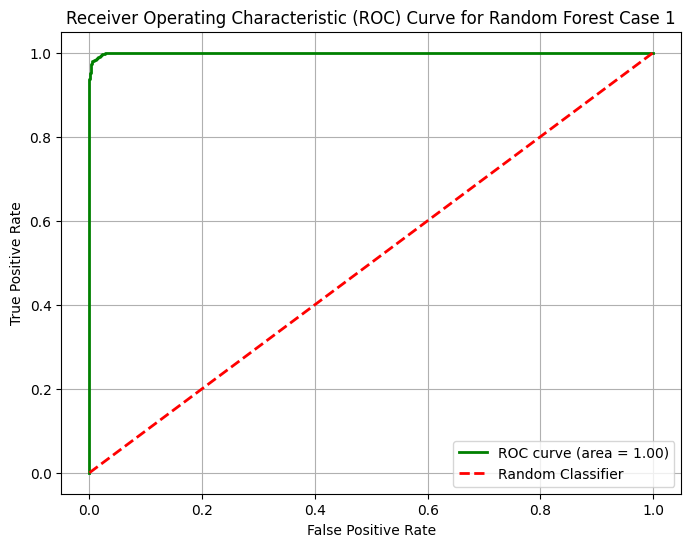

In [ ]:
# Get predicted probabilities for the positive class (spam)
y_prob_rf_c1 = rf_model_c1.predict_proba(X_test_vec_c1)[:, 1]

# Calculate False Positive Rate (FPR)
tn, fp, fn, tp = cm_rf_c1.ravel()
fpr_rf = fp / (fp + tn)
print(f"False Positive Rate (Random Forest): {fpr_rf:.4f}")

# Calculate ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test_c1, y_prob_rf_c1)
print(f"ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")

# Plot ROC Curve
fpr_curve_rf, tpr_curve_rf, _ = roc_curve(y_test_c1, y_prob_rf_c1)

plt.figure(figsize=(8, 6))
plt.plot(fpr_curve_rf, tpr_curve_rf, color='green', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest Case 1')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

False Positive Rate (Random Forest): 0.0188
ROC-AUC Score (Random Forest): 0.9976


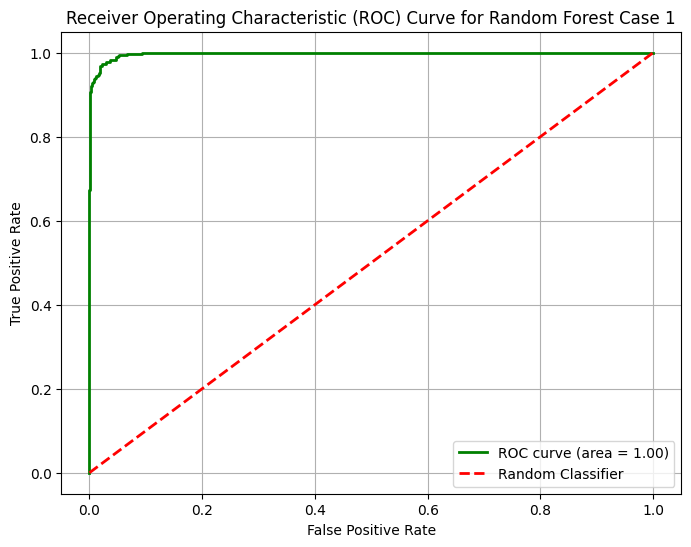

In [ ]:
# Get predicted probabilities for the positive class (spam)
y_prob_rf_c2 = rf_model_c2.predict_proba(X_test_vec_c2)[:, 1]

# Calculate False Positive Rate (FPR)
tn, fp, fn, tp = cm_rf_c2.ravel()
fpr_rf = fp / (fp + tn)
print(f"False Positive Rate (Random Forest): {fpr_rf:.4f}")

# Calculate ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test_c2, y_prob_rf_c2)
print(f"ROC-AUC Score (Random Forest): {roc_auc_rf:.4f}")

# Plot ROC Curve
fpr_curve_rf, tpr_curve_rf, _ = roc_curve(y_test_c2, y_prob_rf_c2)

plt.figure(figsize=(8, 6))
plt.plot(fpr_curve_rf, tpr_curve_rf, color='green', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest Case 1')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Model 3: TF-IDF + LSTM

In [ ]:
# ============================================================
# Model 3: TF-IDF + LSTM (pseudo-sequence reshape)
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score

TIMESTEPS = 100
FEATURES_PER_STEP = 100  # TIMESTEPS * FEATURES_PER_STEP must equal tfidf max_features (10000)

def build_lstm_tfidf_model():
    model = Sequential([
        LSTM(64, input_shape=(TIMESTEPS, FEATURES_PER_STEP)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def reshape_tfidf(X_vec):
    # sparse -> dense -> (n_samples, TIMESTEPS, FEATURES_PER_STEP)
    X_dense = X_vec.toarray().astype('float32')
    return X_dense.reshape(X_dense.shape[0], TIMESTEPS, FEATURES_PER_STEP)

Model 3 mengambil vektor TF-IDF berdimensi 10.000 per dokumen, lalu membentuknya ulang `(reshape)` menjadi tensor berbentuk `(100, 100)` — 100 `timestep` dengan 100 fitur di setiap timestep — supaya bisa diterima oleh layer LSTM di Keras yang memang mensyaratkan input 3D `(batch, timesteps, features)`. Tidak ada proses tokenisasi atau embedding kata di sini; LSTM langsung memproses pecahan-pecahan dari vektor TF-IDF yang sudah jadi.

- TF-IDF mengubah setiap dokumen menjadi satu vektor jarang (sparse) dengan panjang tetap, di mana urutan kata hilang dan setiap dimensi merepresentasikan bobot suatu istilah dalam kosakata.
- LSTM membutuhkan urutan vektor berdasarkan langkah waktu (satu untuk setiap token, sesuai urutan) agar mekanisme rekursifnya dapat bekerja secara efektif.

Pendekatan ini umum dipakai di banyak tutorial dan bahkan beberapa paper yang mengklaim arsitektur "TF-IDF + LSTM": karena LSTM butuh input berbentuk sekuens, sementara TF-IDF menghasilkan satu vektor datar per dokumen, satu-satunya cara membuatnya "kompatibel" adalah memotong vektor tersebut menjadi beberapa segmen dan memperlakukan tiap segmen sebagai satu timestep.

 Secara teoretis performa Model 3 versi ini diperkirakan tidak akan mengungguli, dan kemungkinan besar setara atau bahkan sedikit di bawah, Model 1 (SVM) dan Model 2 (Random Forest) yang langsung memproses vektor TF-IDF apa adanya tanpa asumsi sekuensial yang salah. Jika hasil eksperimen menunjukkan akurasi yang kompetitif, itu kemungkinan besar disebabkan oleh kapasitas LSTM sebagai fungsi non-linear yang kuat (mirip MLP kecil), bukan karena LSTM "memahami sekuens"

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,305 (165.25 KB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM (TF-IDF reshaped) - Case 1
Epoch 1/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7771 - loss: 0.5320 - val_accuracy: 0.7752 - val_loss: 0.5357
Epoch 2/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.8272 - loss: 0.3790 - val_accuracy: 0.8728 - val_loss: 0.3538
Epoch 3/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.9161 - loss: 0.2356 - val_accuracy: 0.9159 - val_loss: 0.2369
Epoch 4/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.9360 - loss: 0.1874 - val_accuracy: 0.9259 - val_loss: 0.1861
Epoch 5/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 38s 63ms/step - accuracy: 0.9454 - loss: 0.1571 - val_accuracy: 0.9268 - val_loss: 0.2281
Epoch 6/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9526 - loss: 0.1398 - val_accuracy: 0.9460 - val_loss: 0.1470
Epoch 7/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.9568 - loss: 0.1281 - val_accuracy: 0.9451 - val_loss: 0.1346
Epoch 8/10
287/287 ━━━━━━━━━━━━━━━━━━━━ 18s 61ms

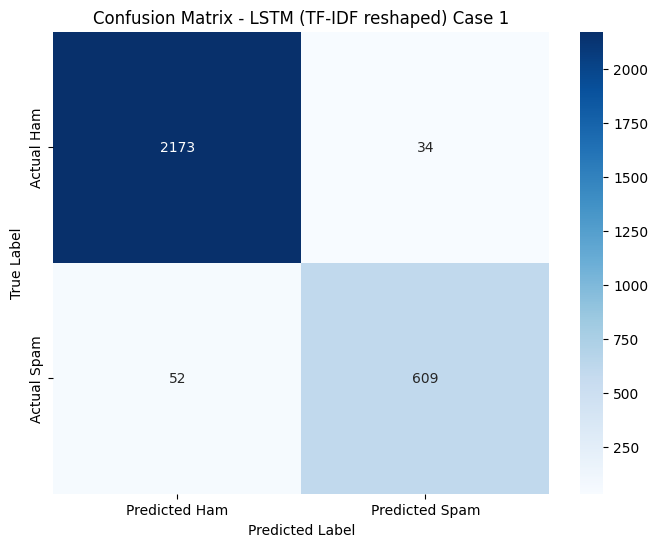

False Positive Rate (Case 1): 0.0154
ROC-AUC Score (Case 1): 0.9913


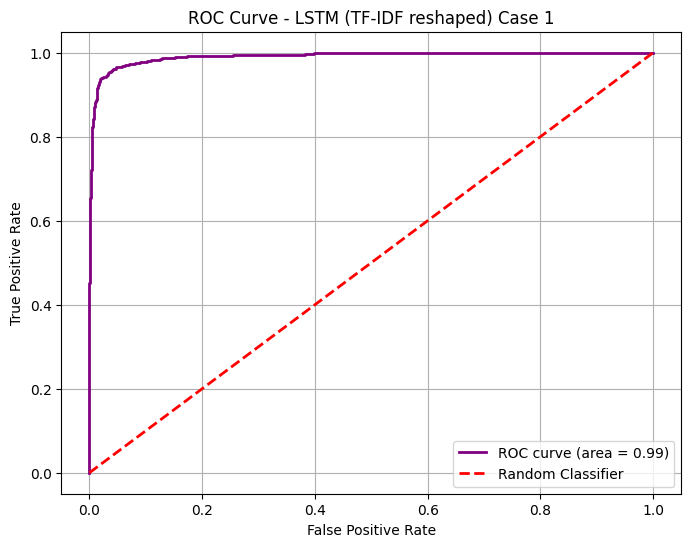

In [ ]:
# =============================
# Case 1
# =============================
X_train_lstm_c1 = reshape_tfidf(X_train_vec_c1)
X_test_lstm_c1 = reshape_tfidf(X_test_vec_c1)
y_train_c1_np = y_train_c1.to_numpy()
y_test_c1_np = y_test_c1.to_numpy()

lstm_tfidf_c1 = build_lstm_tfidf_model()
lstm_tfidf_c1.summary()

print("\nTraining LSTM (TF-IDF reshaped) - Case 1")
history_c1 = lstm_tfidf_c1.fit(
    X_train_lstm_c1, y_train_c1_np,
    epochs=10, batch_size=32,
    validation_split=0.2, verbose=1
)

loss_c1, acc_c1 = lstm_tfidf_c1.evaluate(X_test_lstm_c1, y_test_c1_np, verbose=0)
print(f"\nTest Accuracy (Case 1): {acc_c1:.4f}")

y_prob_lstm_tfidf_c1 = lstm_tfidf_c1.predict(X_test_lstm_c1)
y_pred_lstm_tfidf_c1 = (y_prob_lstm_tfidf_c1 > 0.5).astype(int)

print("=====================================")
print("LSTM (TF-IDF reshaped) Evaluation Case 1:")
print("=====================================")
print(classification_report(y_test_c1_np, y_pred_lstm_tfidf_c1))

cm_lstm_tfidf_c1 = confusion_matrix(y_test_c1_np, y_pred_lstm_tfidf_c1)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm_tfidf_c1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LSTM (TF-IDF reshaped) Case 1')
plt.show()

tn, fp, fn, tp = cm_lstm_tfidf_c1.ravel()
fpr_lstm_tfidf_c1 = fp / (fp + tn)
print(f"False Positive Rate (Case 1): {fpr_lstm_tfidf_c1:.4f}")

roc_auc_lstm_tfidf_c1 = roc_auc_score(y_test_c1_np, y_prob_lstm_tfidf_c1)
print(f"ROC-AUC Score (Case 1): {roc_auc_lstm_tfidf_c1:.4f}")

fpr_curve_c1, tpr_curve_c1, _ = roc_curve(y_test_c1_np, y_prob_lstm_tfidf_c1)
plt.figure(figsize=(8, 6))
plt.plot(fpr_curve_c1, tpr_curve_c1, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_lstm_tfidf_c1:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM (TF-IDF reshaped) Case 1')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM (TF-IDF reshaped) - Case 2
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.6308 - loss: 0.6629 - val_accuracy: 0.7933 - val_loss: 0.5619
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8641 - loss: 0.3452 - val_accuracy: 0.9091 - val_loss: 0.2770
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9160 - loss: 0.2513 - val_accuracy: 0.9129 - val_loss: 0.2421
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9162 - loss: 0.2325 - val_accuracy: 0.9301 - val_loss: 0.2065
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9268 - loss: 0.2038 - val_accuracy: 0.9244 - val_loss: 0.2223
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.9261 - loss: 0.2019 - val_accuracy: 0.9282 - val_loss: 0.2198
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.9347 - loss: 0.1849 - val_accuracy: 0.9416 - val_loss: 0.1946
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step 

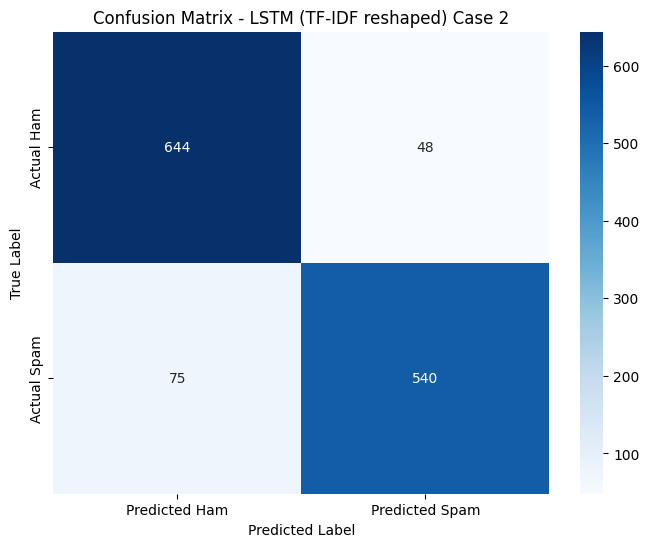

False Positive Rate (Case 2): 0.0694
ROC-AUC Score (Case 2): 0.9612


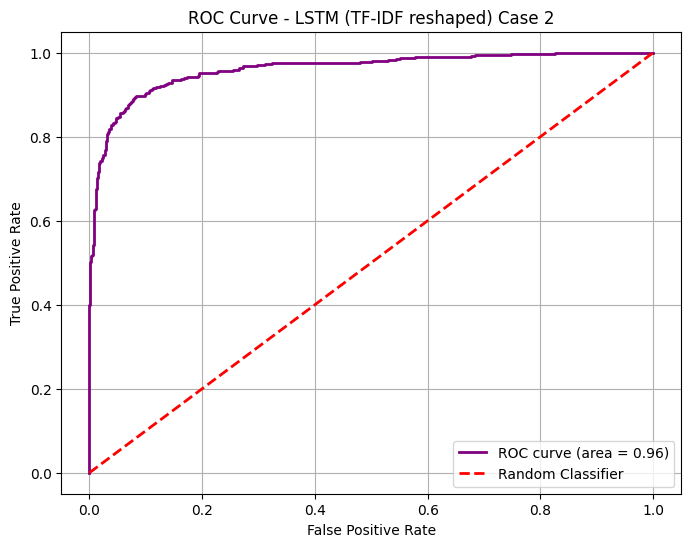

In [ ]:
# =============================
# Case 2
# =============================
X_train_lstm_c2 = reshape_tfidf(X_train_vec_c2)
X_test_lstm_c2 = reshape_tfidf(X_test_vec_c2)
y_train_c2_np = y_train_c2.to_numpy()
y_test_c2_np = y_test_c2.to_numpy()

lstm_tfidf_c2 = build_lstm_tfidf_model()

print("\nTraining LSTM (TF-IDF reshaped) - Case 2")
history_c2 = lstm_tfidf_c2.fit(
    X_train_lstm_c2, y_train_c2_np,
    epochs=10, batch_size=32,
    validation_split=0.2, verbose=1
)

loss_c2, acc_c2 = lstm_tfidf_c2.evaluate(X_test_lstm_c2, y_test_c2_np, verbose=0)
print(f"\nTest Accuracy (Case 2): {acc_c2:.4f}")

y_prob_lstm_tfidf_c2 = lstm_tfidf_c2.predict(X_test_lstm_c2)
y_pred_lstm_tfidf_c2 = (y_prob_lstm_tfidf_c2 > 0.5).astype(int)

print("=====================================")
print("LSTM (TF-IDF reshaped) Evaluation Case 2:")
print("=====================================")
print(classification_report(y_test_c2_np, y_pred_lstm_tfidf_c2))

cm_lstm_tfidf_c2 = confusion_matrix(y_test_c2_np, y_pred_lstm_tfidf_c2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm_tfidf_c2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LSTM (TF-IDF reshaped) Case 2')
plt.show()

tn, fp, fn, tp = cm_lstm_tfidf_c2.ravel()
fpr_lstm_tfidf_c2 = fp / (fp + tn)
print(f"False Positive Rate (Case 2): {fpr_lstm_tfidf_c2:.4f}")

roc_auc_lstm_tfidf_c2 = roc_auc_score(y_test_c2_np, y_prob_lstm_tfidf_c2)
print(f"ROC-AUC Score (Case 2): {roc_auc_lstm_tfidf_c2:.4f}")

fpr_curve_c2, tpr_curve_c2, _ = roc_curve(y_test_c2_np, y_prob_lstm_tfidf_c2)
plt.figure(figsize=(8, 6))
plt.plot(fpr_curve_c2, tpr_curve_c2, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_lstm_tfidf_c2:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LSTM (TF-IDF reshaped) Case 2')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Error Analysis

## Model 1 both cases

In [ ]:
print("=====================================")
print("Misclassified Examples for SVM Model Case 1:")
print("=====================================")

misclassified_df_c1 = pd.DataFrame({
    'text_clean': X_test_c1,
    'actual_label': y_test_c1,
    'predicted_label': y_pred_svm_c1
})

misclassified_df_c1 = misclassified_df_c1[misclassified_df_c1['actual_label'] != misclassified_df_c1['predicted_label']]
display(misclassified_df_c1)

print("\n=====================================")
print("Misclassified Examples for SVM Model Case 2:")
print("=====================================")

misclassified_df_c2 = pd.DataFrame({
    'text_clean': X_test_c2,
    'actual_label': y_test_c2,
    'predicted_label': y_pred_svm_c2
})

misclassified_df_c2 = misclassified_df_c2[misclassified_df_c2['actual_label'] != misclassified_df_c2['predicted_label']]
display(misclassified_df_c2)

Misclassified Examples for SVM Model Case 1:


,text_clean,actual_label,predicted_label
11002,tue aug returnpath deliveredto received localh...,1,0
10500,mon aug returnpath deliveredto received localh...,1,0
13446,tue aug returnpath deliveredto received localh...,1,0
7550,important notification area shaperect coords alt,1,0
5555,messageid date sun dec pst subject put end hai...,0,1
10218,wed jul returnpath deliveredto received localh...,1,0
13688,wed jul returnpath deliveredto received localh...,1,0
1202,messageid date tue nov pst subject power index...,0,1
6854,messageid date fri nov pst subject november ed...,0,1



Misclassified Examples for SVM Model Case 2:


,text_clean,actual_label,predicted_label
4078,fri jul returnpath deliveredto received localh...,1,0
3727,thu aug returnpath deliveredto received localh...,1,0
5798,fri aug returnpath deliveredto received localh...,1,0
4846,fri aug returnpath deliveredto received localh...,1,0
6746,xstatus xkeywords returnpath deliveredto recei...,1,0
5361,thu nov returnpath deliveredto received localh...,1,0
839,messageid date wed feb pst subject associate a...,0,1
5971,mon jul returnpath deliveredto received localh...,1,0
7834,wed jul returnpath deliveredto received localh...,0,1
5301,fri aug returnpath deliveredto received localh...,1,0


## Model 2 both cases

In [ ]:
print("=====================================")
print("Misclassified Examples for Random Forest Model Case 1:")
print("=====================================")

misclassified_df_rf_c1 = pd.DataFrame({
    'text_clean': X_test_c1,
    'actual_label': y_test_c1,
    'predicted_label': y_pred_rf_c1
})

misclassified_df_rf_c1 = misclassified_df_rf_c1[misclassified_df_rf_c1['actual_label'] != misclassified_df_rf_c1['predicted_label']]
display(misclassified_df_rf_c1)

print("\n=====================================")
print("Misclassified Examples for Random Forest Model Case 2:")
print("=====================================")

misclassified_df_rf_c2 = pd.DataFrame({
    'text_clean': X_test_c2,
    'actual_label': y_test_c2,
    'predicted_label': y_pred_rf_c2
})

misclassified_df_rf_c2 = misclassified_df_rf_c2[misclassified_df_rf_c2['actual_label'] != misclassified_df_rf_c2['predicted_label']]
display(misclassified_df_rf_c2)

Misclassified Examples for Random Forest Model Case 1:


,text_clean,actual_label,predicted_label
10118,sat sep returnpath deliveredto received localh...,1,0
9366,thu aug returnpath deliveredto received localh...,1,0
10891,wed jul returnpath deliveredto received localh...,1,0
11002,tue aug returnpath deliveredto received localh...,1,0
10935,thu aug returnpath deliveredto received localh...,1,0
9631,returnpath deliverydate mon sep greg ward date...,0,1
9914,mon sep returnpath deliveredto received localh...,1,0
9868,thu aug returnpath deliveredto received localh...,1,0
13079,sat sep returnpath deliveredto received localh...,1,0
10500,mon aug returnpath deliveredto received localh...,1,0



Misclassified Examples for Random Forest Model Case 2:


,text_clean,actual_label,predicted_label
4078,fri jul returnpath deliveredto received localh...,1,0
3578,returnpath deliverydate tue sep skip montanaro...,0,1
2801,tue sep returnpath deliveredto received localh...,1,0
3781,thu aug returnpath deliveredto received localh...,1,0
5982,tue jul returnpath deliveredto received localh...,1,0
4000,mon aug returnpath deliveredto received localh...,1,0
3727,thu aug returnpath deliveredto received localh...,1,0
6843,tue aug returnpath deliveredto received localh...,0,1
4601,fri sep returnpath deliveredto received localh...,1,0
6860,wed aug returnpath deliveredto received localh...,0,1


## Model 3 both cases

In [ ]:
print("=====================================")
print("Misclassified Examples for LSTM Model Case 1:")
print("=====================================")

misclassified_df_lstm_c1 = pd.DataFrame({
    'text_clean': X_test_c1,
    'actual_label': y_test_c1_np,
    'predicted_label': y_pred_lstm_tfidf_c1.flatten() # Flatten to match Series/array
})

misclassified_df_lstm_c1 = misclassified_df_lstm_c1[misclassified_df_lstm_c1['actual_label'] != misclassified_df_lstm_c1['predicted_label']]
display(misclassified_df_lstm_c1)

print("\n=====================================")
print("Misclassified Examples for LSTM Model Case 2:")
print("=====================================")

misclassified_df_lstm_c2 = pd.DataFrame({
    'text_clean': X_test_c2,
    'actual_label': y_test_c2_np,
    'predicted_label': y_pred_lstm_tfidf_c2.flatten() # Flatten to match Series/array
})

misclassified_df_lstm_c2 = misclassified_df_lstm_c2[misclassified_df_lstm_c2['actual_label'] != misclassified_df_lstm_c2['predicted_label']]
display(misclassified_df_lstm_c2)

Misclassified Examples for LSTM Model Case 1:


,text_clean,actual_label,predicted_label
2353,messageid date fri aug pdt subject trading edg...,0,1
1991,messageid date sun apr pdt subject schedule cr...,0,1
10118,sat sep returnpath deliveredto received localh...,1,0
4128,messageid date mon oct pdt subject natural gas...,0,1
4663,messageid date tue jan pst subject staga tenta...,0,1
...,...,...,...
11326,fri aug returnpath deliveredto received localh...,1,0
6854,messageid date fri nov pst subject november ed...,0,1
11920,tue jul returnpath deliveredto received localh...,1,0
12285,received hqpronsnet localhost hqpronsnet esmtp...,1,0



Misclassified Examples for LSTM Model Case 2:


,text_clean,actual_label,predicted_label
4091,mon sep returnpath deliveredto received localh...,1,0
3024,received hqpronsnet localhost hqpronsnet esmtp...,1,0
6179,mon jun returnpath deliverydate tue may receiv...,1,0
2351,smarsh email encryption activation information...,1,0
5796,thu jul returnpath deliveredto received localh...,0,1
...,...,...,...
2756,wed sep returnpath deliveredto received localh...,1,0
6518,mon dec returnpath deliveredto received localh...,1,0
7520,thu aug returnpath deliveredto received localh...,1,0
2703,returnpath deliverydate sat sep skip montanaro...,0,1


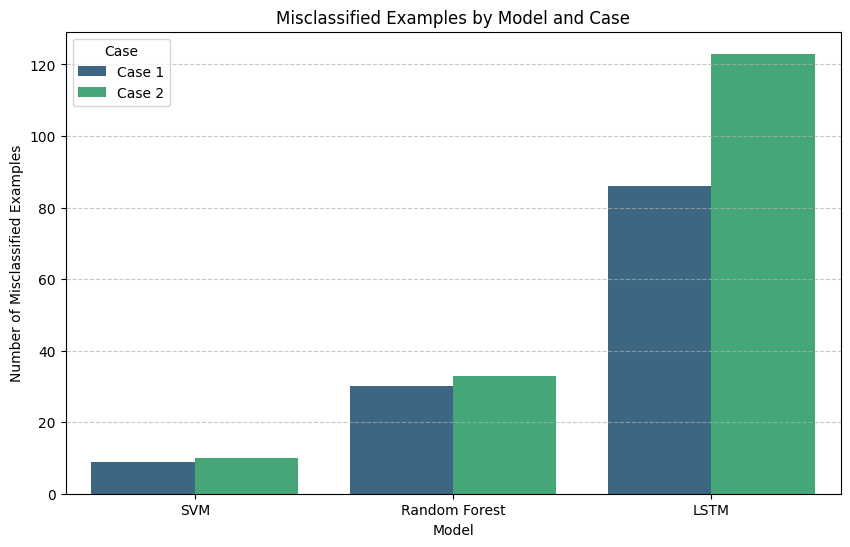

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the number of misclassified examples for each model and case
svm_misclassified_c1 = len(misclassified_df_c1)
svm_misclassified_c2 = len(misclassified_df_c2)

rf_misclassified_c1 = len(misclassified_df_rf_c1)
rf_misclassified_c2 = len(misclassified_df_rf_c2)

lstm_misclassified_c1 = len(misclassified_df_lstm_c1)
lstm_misclassified_c2 = len(misclassified_df_lstm_c2)

# Create a DataFrame for plotting
data = {
    'Model': ['SVM', 'SVM', 'Random Forest', 'Random Forest', 'LSTM', 'LSTM'],
    'Case': ['Case 1', 'Case 2', 'Case 1', 'Case 2', 'Case 1', 'Case 2'],
    'Misclassified Count': [
        svm_misclassified_c1, svm_misclassified_c2,
        rf_misclassified_c1, rf_misclassified_c2,
        lstm_misclassified_c1, lstm_misclassified_c2
    ]
}
error_analysis_df = pd.DataFrame(data)

# Plotting the error analysis
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Misclassified Count', hue='Case', data=error_analysis_df, palette='viridis')
plt.title('Misclassified Examples by Model and Case')
plt.xlabel('Model')
plt.ylabel('Number of Misclassified Examples')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Export misclassified examples for SVM Model Case 1
misclassified_df_c1.to_csv('svm_misclassified_case1.csv', index=False)
print("svm_misclassified_case1.csv exported.")

# Export misclassified examples for SVM Model Case 2
misclassified_df_c2.to_csv('svm_misclassified_case2.csv', index=False)
print("svm_misclassified_case2.csv exported.")

# Export misclassified examples for Random Forest Model Case 1
misclassified_df_rf_c1.to_csv('rf_misclassified_case1.csv', index=False)
print("rf_misclassified_case1.csv exported.")

# Export misclassified examples for Random Forest Model Case 2
misclassified_df_rf_c2.to_csv('rf_misclassified_case2.csv', index=False)
print("rf_misclassified_case2.csv exported.")

# Export misclassified examples for LSTM Model Case 1
misclassified_df_lstm_c1.to_csv('lstm_misclassified_case1.csv', index=False)
print("lstm_misclassified_case1.csv exported.")

# Export misclassified examples for LSTM Model Case 2
misclassified_df_lstm_c2.to_csv('lstm_misclassified_case2.csv', index=False)
print("lstm_misclassified_case2.csv exported.")

svm_misclassified_case1.csv exported.
svm_misclassified_case2.csv exported.
rf_misclassified_case1.csv exported.
rf_misclassified_case2.csv exported.
lstm_misclassified_case1.csv exported.
lstm_misclassified_case2.csv exported.
